Using pandas answer at least 4 of the 6 questions you wrote in the first part of your project. 

Include code to generate at least one data visualization or summary table as output, and 2-3 sentences of written interpretation of what you found.

You are expected to use a variety of pandas operations in your notebook. You can use...

- groupby() to aggregate data across a categorical column.

- pivot_table() to summarize a relationship between two categorical variables.

- boolean filtering to isolate a subset of the data to answer a specific question.

Your notebook should be readable from top to bottom, as if it was a short report. 
Use markdown cells to format your report to:

- title each section with the question you're investigating 
- your interpretation after each output

------------------------------------------------------------------------------------------------------------

Possible Questions to Analyze: 6 Original, 4 Assigned

**NOTE:**

**!!! Questions asked and answered are subject to CHANGE over process !!!**



----------Original Questions -----------

1: Which season do shoppers spend the most amount per purchase, and what factors influence those decisions?

2: ~~How many promo codes were offered versus actually utilized? How many were unused?~~

**Due to insufficient/missing data, this question will not be answered at this time**

3: ~~Does the frequency of purchases effect purchase costs? What is the relationship between frequency and costs?~~

**Due to insufficient/missing data, this question will not be answered at this time**

4: Which seasons were most popular with buyers in each state, and which items in turn?

5: What sizes of clothes were most purchased, and which items? Which sizes shopped with this company the most overall?

6: ~~What is the probability of success if more promo codes were offered/used in each season? What would change the effect?~~

**Due to limits of scope of assignment, this question will not be answered at this time**

---------- Assigned Questions -----------

1: What are the most popular colors by season?

2: What is the most popular clothing item by season?

3: What is the effect of promo codes on the dollar amount of purchases?

4: ~~When do users leave a review?~~

**Due to insufficient/missing data, this question will not be answered at this time**


In [1]:
import pandas as pandy
import matplotlib.pyplot as mattyp
import numpy as numpy

shopping_df = pandy.read_csv('data/raw/shopping.csv')

shopping_df.head()

,Customer ID,Age,Gender,Item Purchased,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Shipping Type,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,3475,NaN,Male,Jacket,30.904467,Maine,M,Burnt orange,Fall,4.0,Standard,No,0,Credit Card,NaN
1,3698,21.0,Female,Backpack,31.588259,NaN,L,Turquoise,Winter,2.0,Express,No,1,Credit Card,Monthly
2,2756,31.0,Male,Leggings,24.231704,Nevada,M,Terra cotta,Winter,4.0,Standard,No,0,Credit Card,NaN
3,3340,NaN,Male,Pajamas,33.918834,Nebraska,M,Black,Winter,NaN,Standard,No,2,Credit Card,Bi-Weekly
4,3391,38.0,Male,Sunglasses,36.545487,Oregon,S,Aubergine,Summer,NaN,Standard,No,0,Credit Card,NaN


In [3]:
shopping_df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3510.000000,3900.000000,1431.000000,3900.000000
mean,1950.500000,34.256695,38.708329,3.904962,5.841538
std,1125.977353,10.616340,11.504923,1.105952,5.843695
min,1.000000,18.000000,11.392520,1.000000,0.000000
25%,975.750000,26.000000,29.332617,4.000000,1.000000
50%,1950.500000,33.000000,36.953004,4.000000,4.000000
75%,2925.250000,41.000000,48.739596,5.000000,9.000000
max,3900.000000,75.000000,69.567481,5.000000,20.000000


In [2]:
# Note the different amounts of non-null values, pointing to missing values

shopping_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3510 non-null   float64
 2   Gender                  3900 non-null   str    
 3   Item Purchased          3900 non-null   str    
 4   Purchase Amount (USD)   3900 non-null   float64
 5   Location                3510 non-null   str    
 6   Size                    3900 non-null   str    
 7   Color                   3900 non-null   str    
 8   Season                  3900 non-null   str    
 9   Review Rating           1431 non-null   float64
 10  Shipping Type           3900 non-null   str    
 11  Promo Code Used         3900 non-null   str    
 12  Previous Purchases      3900 non-null   int64  
 13  Payment Method          3900 non-null   str    
 14  Frequency of Purchases  1560 non-null   str    
dty

In [15]:
# There are missing values in multiple rows and columns that make the data harder to analyze
# I need to find a way to clean the data and fill in the missing values
# False values are not missing, while true values are missing

missing_values = shopping_df.isnull()
print(missing_values)

      Customer ID    Age  Gender  Item Purchased  Purchase Amount (USD)  \
0           False   True   False           False                  False   
1           False  False   False           False                  False   
2           False  False   False           False                  False   
3           False   True   False           False                  False   
4           False  False   False           False                  False   
...           ...    ...     ...             ...                    ...   
3895        False  False   False           False                  False   
3896        False  False   False           False                  False   
3897        False   True   False           False                  False   
3898        False  False   False           False                  False   
3899        False  False   False           False                  False   

      Location   Size  Color  Season  Review Rating  Shipping Type  \
0        False  False  False 

In [16]:
# This is a count of all the NaN/missing values in the dataset
# Age and Location are missing both 390 in each, which is interesting
# Review Rating and Frequency of Purchases are both missing the vast majority of values, which makes them less useful for analysis

null_counts = shopping_df.isnull().sum()
print(null_counts)

Customer ID                  0
Age                        390
Gender                       0
Item Purchased               0
Purchase Amount (USD)        0
Location                   390
Size                         0
Color                        0
Season                       0
Review Rating             2469
Shipping Type                0
Promo Code Used              0
Previous Purchases           0
Payment Method               0
Frequency of Purchases    2340
dtype: int64


In [24]:
# I used .fillna to fill in missing values with mean and mode
# Not sure if it would be better to just drop the rows, but I thought it would be better to salvage the data instead
# Review Rating and Frequency of Purchase are the most unreliable data sets, so I will not be relying on them for analysis

clean_shopping_df = shopping_df.copy()
clean_shopping_df['Age'] = clean_shopping_df['Age'].fillna(clean_shopping_df['Age'].mean())
clean_shopping_df['Location'] = clean_shopping_df['Location'].fillna(clean_shopping_df['Location'].mode()[0])
clean_shopping_df['Review Rating'] = clean_shopping_df['Review Rating'].fillna(clean_shopping_df['Review Rating'].mean())
clean_shopping_df['Frequency of Purchases'] = clean_shopping_df['Frequency of Purchases'].fillna(clean_shopping_df['Frequency of Purchases'].mode()[0])

print(clean_shopping_df.info())

<class 'pandas.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   float64
 2   Gender                  3900 non-null   str    
 3   Item Purchased          3900 non-null   str    
 4   Purchase Amount (USD)   3900 non-null   float64
 5   Location                3900 non-null   str    
 6   Size                    3900 non-null   str    
 7   Color                   3900 non-null   str    
 8   Season                  3900 non-null   str    
 9   Review Rating           3900 non-null   float64
 10  Shipping Type           3900 non-null   str    
 11  Promo Code Used         3900 non-null   str    
 12  Previous Purchases      3900 non-null   int64  
 13  Payment Method          3900 non-null   str    
 14  Frequency of Purchases  3900 non-null   str    
dty

In [45]:
# Rounding the data helps with readability

clean_shopping_df.round(2)

,Customer ID,Age,Gender,Item Purchased,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Shipping Type,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,3475,34.26,Male,Jacket,30.90,Maine,M,Burnt orange,Fall,4.0,Standard,No,0,Credit Card,Quarterly
1,3698,21.00,Female,Backpack,31.59,California,L,Turquoise,Winter,2.0,Express,No,1,Credit Card,Monthly
2,2756,31.00,Male,Leggings,24.23,Nevada,M,Terra cotta,Winter,4.0,Standard,No,0,Credit Card,Quarterly
3,3340,34.26,Male,Pajamas,33.92,Nebraska,M,Black,Winter,3.9,Standard,No,2,Credit Card,Bi-Weekly
4,3391,38.00,Male,Sunglasses,36.55,Oregon,S,Aubergine,Summer,3.9,Standard,No,0,Credit Card,Quarterly
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3895,147,43.00,Female,Sunglasses,61.61,Colorado,S,Burnt orange,Fall,3.9,2-Day Shipping,Yes,7,Venmo,Quarterly
3896,1472,37.00,Male,Pajamas,44.60,Alaska,S,Aubergine,Winter,4.0,2-Day Shipping,Yes,20,Venmo,Quarterly
3897,1069,34.26,Female,Handbag,41.78,Wyoming,M,Fuchsia,Summer,3.9,Standard,Yes,13,Venmo,Quarterly
3898,1171,39.00,Male,Hoodie,45.34,Illinois,S,Brick red,Fall,3.9,2-Day Shipping,Yes,3,Venmo,Quarterly


In [53]:
# First grouping was done to the age column, but still very broad range of ages 

clean_shopping_df['Age'] = clean_shopping_df['Age'].round(2)
clean_shopping_df.groupby(['Age']).mean(numeric_only=True).round(2)


,Customer ID,Purchase Amount (USD),Review Rating,Previous Purchases
Age,,,,
18.00,1898.75,39.18,4.01,6.17
19.00,2061.55,37.60,3.96,6.63
20.00,1872.69,39.50,3.84,5.92
21.00,1796.63,40.10,3.93,5.46
22.00,1868.38,38.74,3.77,6.30
23.00,2060.95,36.85,3.90,5.92
24.00,1919.23,38.79,3.86,5.36
25.00,1914.14,38.46,3.86,5.49
26.00,1969.65,38.79,3.91,6.69


In [151]:
# Utilized Age_bins to group the ages into 3 categories for easier analysis

clean_shopping_df['Age_bins'] = pandy.cut( clean_shopping_df['Age'], bins=3, labels=['Young', 'Middle-Aged', 'Old'])

group_by_age_bins = clean_shopping_df[['Age_bins', 'Purchase Amount (USD)', 'Review Rating', 'Previous Purchases']].groupby(['Age_bins']).mean(numeric_only=True).round(2)
group_by_age_bins.index.name = 'Age Range'

print("Average Purchase (USD) by Age Range")
group_by_age_bins

Average Purchase (USD) by Age Range


,Purchase Amount (USD),Review Rating,Previous Purchases
Age Range,,,
Young,38.75,3.90,5.93
Middle-Aged,38.62,3.93,5.61
Old,38.72,3.92,5.93


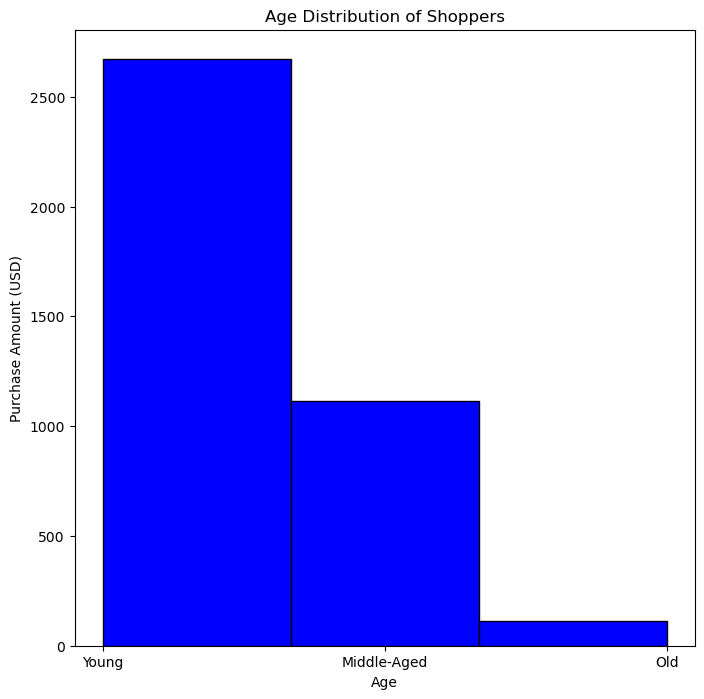

In [ ]:
#Age_Range_Hist = ???
# Not sure how to change the y axis to show purchase amount instead of frequency

mattyp.figure(figsize=(8, 8))
mattyp.hist(clean_shopping_df['Age_bins'], bins=3,color='blue', edgecolor='black')
mattyp.title('Age Distribution of Shoppers')
mattyp.xlabel('Age')
mattyp.ylabel('Purchase Amount (USD)')
mattyp.show()

**Question #1:  How does age influence purchases?**

The purchase amount is fairly equal across all three age groups, with the young crowd spending the most and middle-aged crowd spending the least. My histogram is incorrect and needs to be readjusted. It seems likely that the younger the buyer is, the more they were likely to spend. Overall, the average amount spent across all ages was approx $38. 

------------------------------------------------------------


In [67]:
group_by_seasons = clean_shopping_df[['Season', 'Purchase Amount (USD)','Location', 'Gender', 'Item Purchased', 'Color']].groupby(['Season']).mean(numeric_only=True).round(2)

group_by_seasons

,Purchase Amount (USD)
Season,
Fall,38.83
Spring,39.29
Summer,38.69
Winter,38.37


In [93]:
pivot_age_df = clean_shopping_df.pivot_table(index='Age_bins', columns = ['Location'], values=['Purchase Amount (USD)']).round(2)

pivot_age_df

Purchase Amount (USD)                                              \
Location                  Alabama Alaska Arizona Arkansas California Colorado   
Age_bins                                                                        
Young                       37.35  37.09   36.78    40.09      38.57    35.30   
Middle-Aged                 34.63  34.25   37.29    39.31      37.71    40.47   
Old                         35.71  17.84   30.67    38.86      37.34    42.05   

                                                  ...                         \
Location    Connecticut Delaware Florida Georgia  ... South Dakota Tennessee   
Age_bins                                          ...                          
Young             34.19    37.11   41.54   37.16  ...        37.59     38.19   
Middle-Aged       36.97    41.88   37.26   40.71  ...        37.77     37.70   
Old               43.90    39.27     NaN     NaN  ...          NaN     23.48   

                                                                               \
Location     Texas   Utah Vermont Virginia Washington West Virginia Wisconsin   
Age_bins                                                                        
Young        37.31  40.60   37.25    36.48      38.13         41.37     37.70   
Middle-Aged  40.47  35.11   38.63    41.86      39.62         36.64     41.77   
Old          37.00  34.11   37.43    44.03      47.96         55.66       NaN   

                     
Location    Wyoming  
Age_bins             
Young         38.43  
Middle-Aged   37.03  
Old           24.07  

[3 rows x 50 columns]

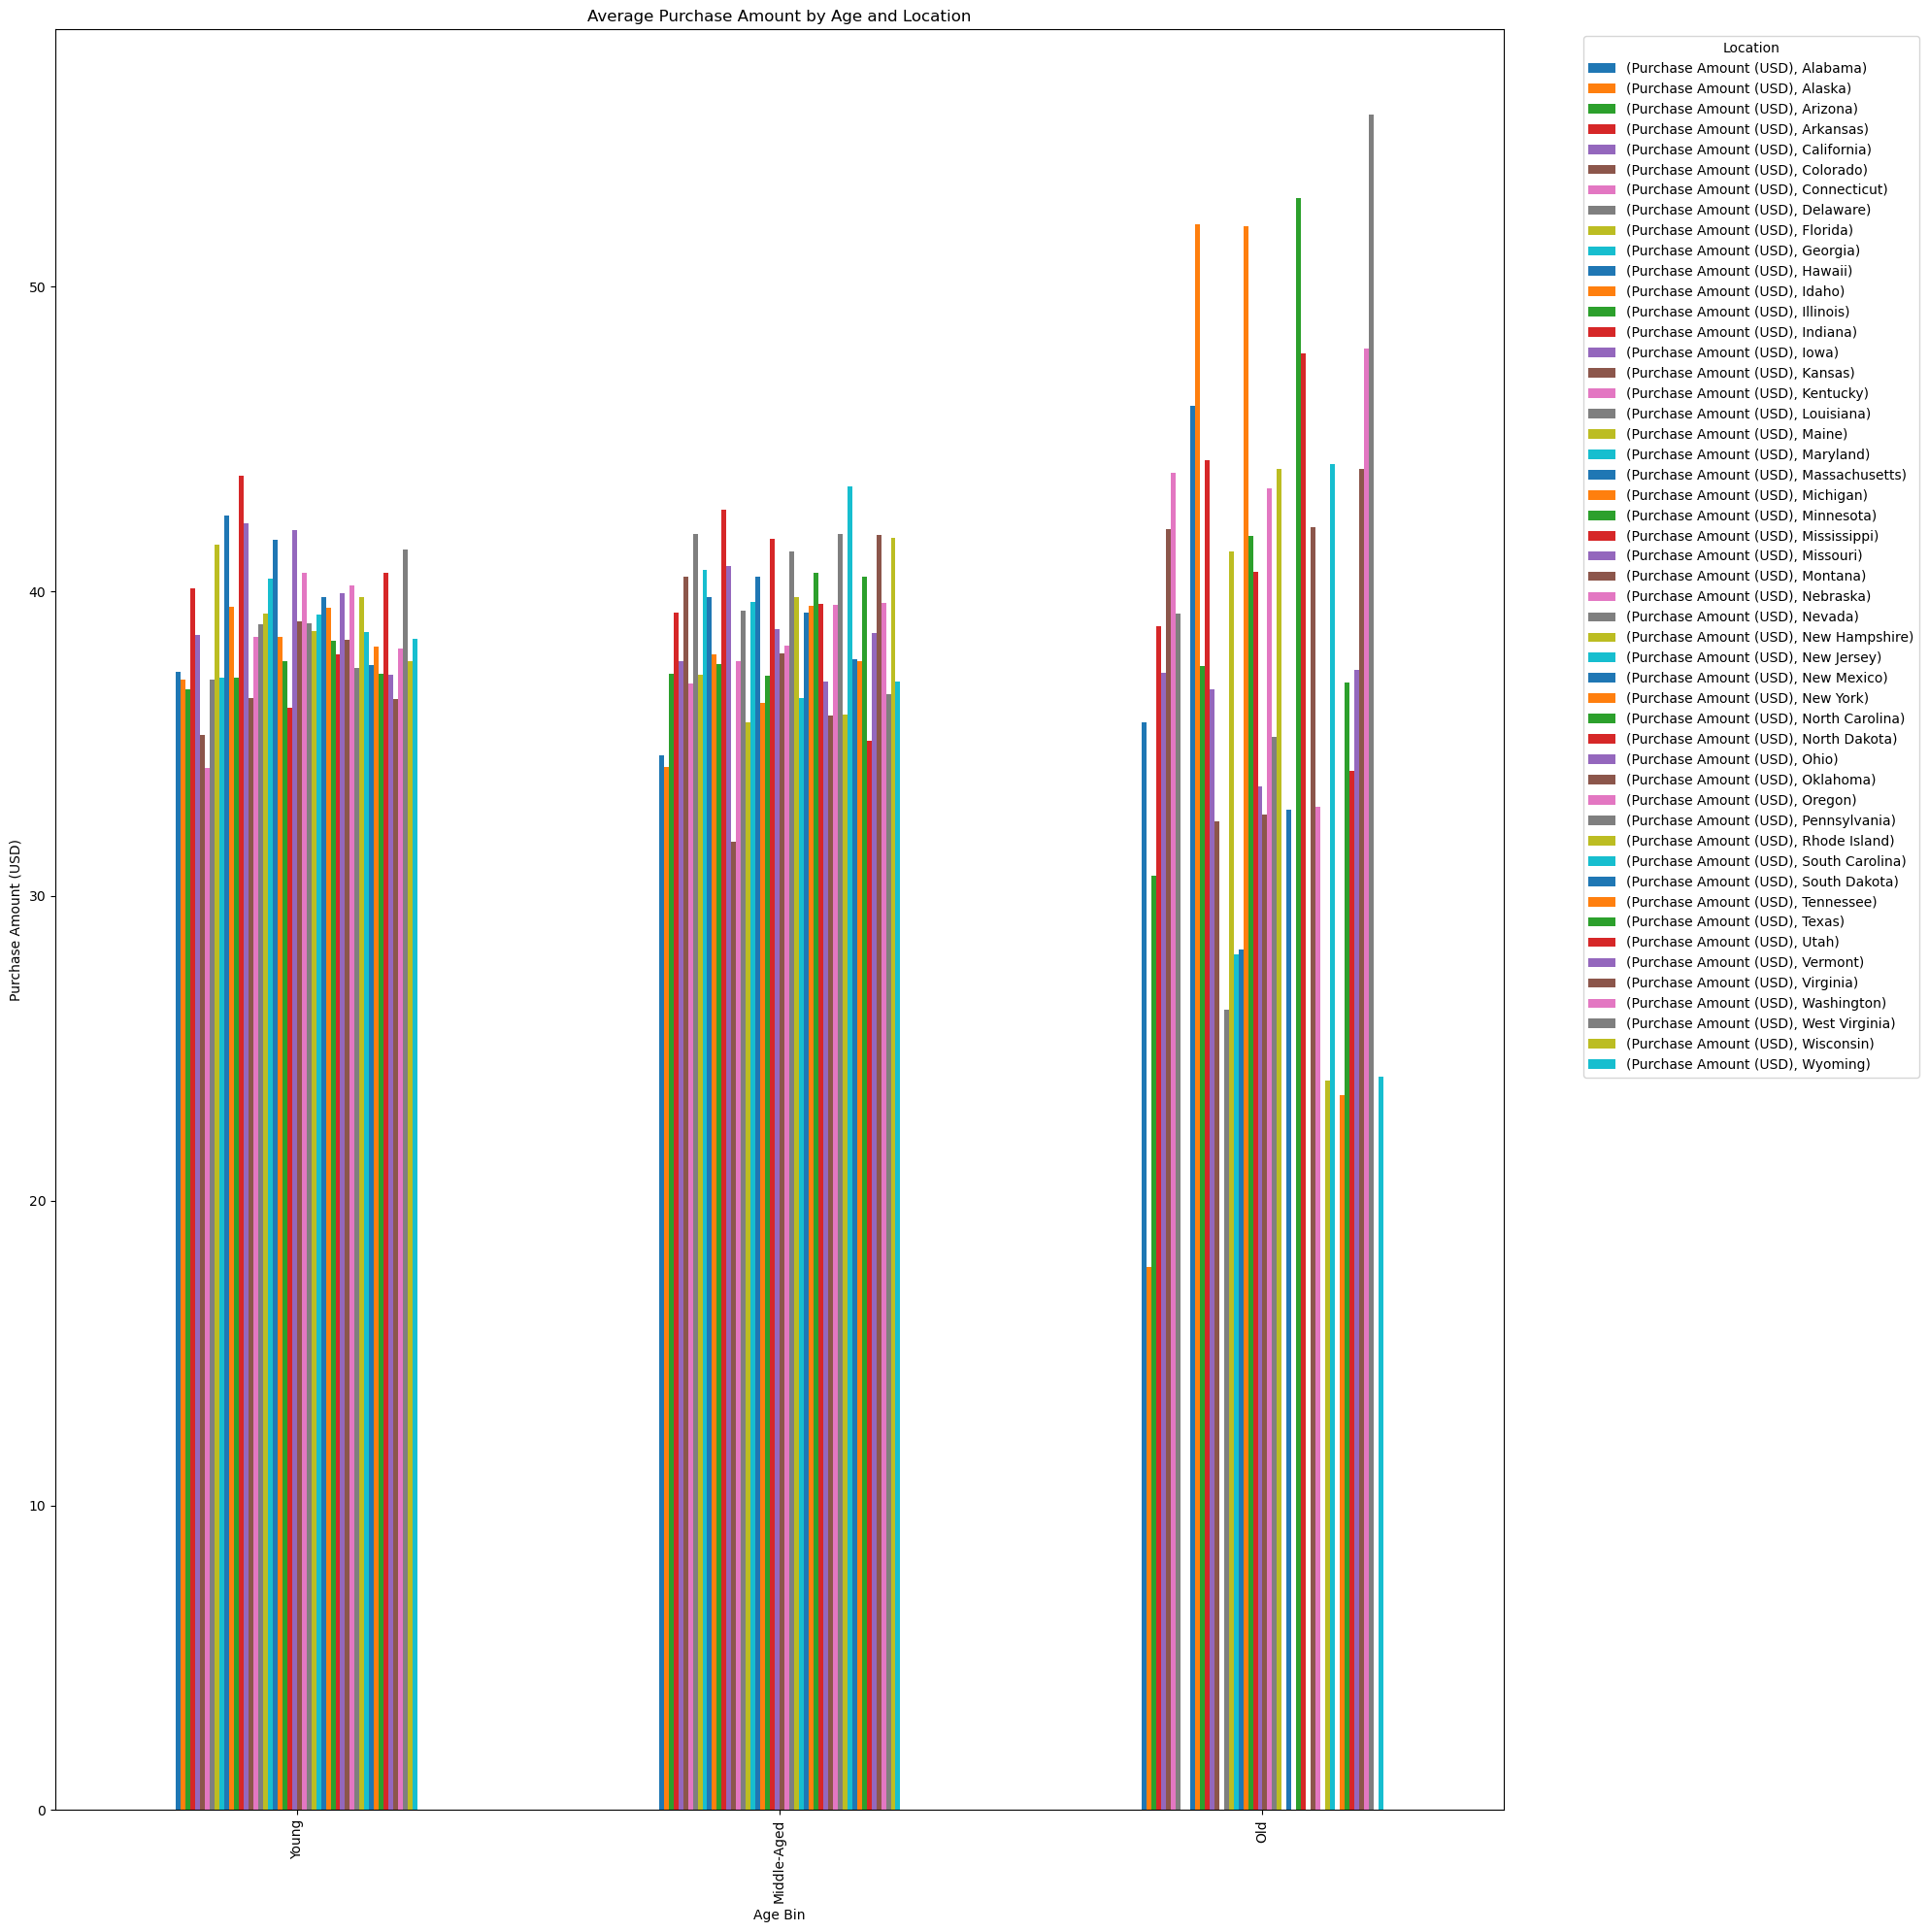

In [107]:
# I was not sure how to visualize this dataset, what could be better?

pivot_age_df.plot(kind='bar', figsize=(20, 20))

mattyp.title('Average Purchase Amount by Age and Location')
mattyp.xlabel('Age Bin')
mattyp.ylabel('Purchase Amount (USD)')
mattyp.legend(title='Location', bbox_to_anchor=(1.05, 1), loc='upper left')
mattyp.tight_layout()

mattyp.show()

**Question 2: What is the relationship between age, location and average purchase amount?**

We know from prior analysis that the young age group purchases cost a higher amount on average than both the middle-aged and older groups. But the differences were small, in the decimal places. With the bar graph we can see that there are certain locations that are outliers among the dataset, particularly in the old group, with avg purchases over $50. The young group has more consistent numbers throughout the locations. There's so many locations though that it's hard to tell from this visualization which specific locations are the outliers. Perhaps I can revisit this dataset later on to further analyze these outliers and relationship using IQR, or a different visualization. It's possible that the outliers in the old group are skewing the data, and that perhaps the middle-aged group spends more on average consistently instead.

-------------------------------------------------------------------------------------------

In [108]:
pivot_gender_df = clean_shopping_df.pivot_table(index='Gender', columns = ['Location'], values=['Purchase Amount (USD)'], aggfunc='sum', margins=True, margins_name='Total').round(2)

print("Purchase Amount Totals by Gender and Location")
pivot_gender_df

Purchase Amount Totals by Gender and Location


Purchase Amount (USD)                                        \
Location                 Alabama   Alaska  Arizona Arkansas California   
Gender                                                                   
Female                   1371.91  1096.45   834.12  1369.31    8968.38   
Male                     1587.72  1258.51  1328.26  1413.15    9240.98   
Non-binary                   NaN      NaN    36.88      NaN     193.12   
Total                    2959.63  2354.97  2199.26  2782.45   18402.48   

                                                            ...            \
Location   Colorado Connecticut Delaware  Florida  Georgia  ... Tennessee   
Gender                                                      ...             
Female      1306.47     1295.59  1331.89  1224.61  1513.40  ...   1265.24   
Male        1116.71     1053.90  1701.54  1236.61  1199.53  ...   1212.25   
Non-binary      NaN         NaN   107.43      NaN      NaN  ...     58.31   
Total       2423.18     2349.48  3140.87  2461.22  2712.93  ...   2535.80   

                                                                         \
Location      Texas     Utah  Vermont Virginia Washington West Virginia   
Gender                                                                    
Female      1233.10  1199.93  1312.00  1297.55    1107.60       1494.57   
Male        1574.46  1335.75  1537.41  1385.93    1202.11       1547.51   
Non-binary    34.74    37.66      NaN      NaN     134.38         85.46   
Total       2842.30  2573.35  2849.41  2683.48    2444.09       3127.54   

                                          
Location   Wisconsin  Wyoming      Total  
Gender                                    
Female       1134.07   865.77   73620.71  
Male         1550.12  1485.82   76032.29  
Non-binary     22.84      NaN    1309.49  
Total        2707.03  2351.59  150962.48  

[4 rows x 51 columns]

In [109]:
clean_shopping_df

,Customer ID,Age,Gender,Item Purchased,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Shipping Type,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases,Age_bins
0,3475,34.26,Male,Jacket,30.904467,Maine,M,Burnt orange,Fall,4.000000,Standard,No,0,Credit Card,Quarterly,Young
1,3698,21.00,Female,Backpack,31.588259,California,L,Turquoise,Winter,2.000000,Express,No,1,Credit Card,Monthly,Young
2,2756,31.00,Male,Leggings,24.231704,Nevada,M,Terra cotta,Winter,4.000000,Standard,No,0,Credit Card,Quarterly,Young
3,3340,34.26,Male,Pajamas,33.918834,Nebraska,M,Black,Winter,3.904962,Standard,No,2,Credit Card,Bi-Weekly,Young
4,3391,38.00,Male,Sunglasses,36.545487,Oregon,S,Aubergine,Summer,3.904962,Standard,No,0,Credit Card,Quarterly,Middle-Aged
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3895,147,43.00,Female,Sunglasses,61.610602,Colorado,S,Burnt orange,Fall,3.904962,2-Day Shipping,Yes,7,Venmo,Quarterly,Middle-Aged
3896,1472,37.00,Male,Pajamas,44.600556,Alaska,S,Aubergine,Winter,4.000000,2-Day Shipping,Yes,20,Venmo,Quarterly,Young
3897,1069,34.26,Female,Handbag,41.781965,Wyoming,M,Fuchsia,Summer,3.904962,Standard,Yes,13,Venmo,Quarterly,Young
3898,1171,39.00,Male,Hoodie,45.343778,Illinois,S,Brick red,Fall,3.904962,2-Day Shipping,Yes,3,Venmo,Quarterly,Middle-Aged


In [ ]:
# What is the most popular color by season?
# I don't know why this got bugged out, how could I format this better?

most_popular_color_by_season = (clean_shopping_df.groupby(['Season', 'Color']).size().reset_index(name='count').sort_values(['Season', 'count'], ascending=[True, False]).drop_duplicates(subset=['Season']))

most_popular_color_by_season

,Season,Color,count
4,Fall,Brown,117
18,Spring,Baby blue,83
41,Summer,Lavender,120
53,Winter,Black,155


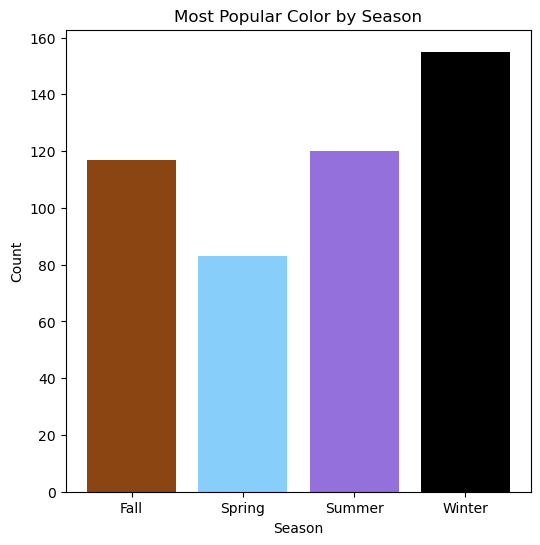

In [173]:
# What is the most popular color by season?


top_colors = most_popular_color_by_season.set_index('Season')

mattyp.figure(figsize=(6, 6))
bar_colors = ['saddlebrown', 'lightskyblue', 'mediumpurple', 'black']
mattyp.bar(top_colors.index, top_colors['count'], color=bar_colors)
mattyp.title('Most Popular Color by Season')
mattyp.xlabel('Season')
mattyp.ylabel('Count')

mattyp.show()

**Question #3: What is the most popular color by season?**

I was challenged by this one, and yet I had fun with it as well! I matched the colors in the visualization with the most popular colors by season. I couldn't figure out how to reorder the seasons in order, and will need to readjust down the line. In any case: Spring's most popular color is baby blue with 83 purchases, Summer is lavender with 120 purchases, Fall is brown with 117 purchases, and Winter is Black with the most purchases of 155. The color choices are interesting and seem to reflect the seasonal patterns, with lighter colors in the warmer seasons and darker colors in the colder seasons. Winter having the most purchases might be because of the holidays, but that is only a guess. Further analysis could be useful here.

-----------------------------------------------------------------------------------

In [ ]:
# What is the most popular item by size?

clean_shopping_df['Size'] = pandy.Categorical(
    clean_shopping_df['Size'],
    categories=['S', 'M', 'L', 'XL'],
    ordered=True
)

most_popular_item_by_size = (
    clean_shopping_df
    .groupby(['Size', 'Item Purchased'])
    .size()
    .reset_index(name='count')
    .sort_values(['Size', 'count'], ascending=[True, False])
    .drop_duplicates(subset=['Size'])
)

most_popular_item_by_size

,Size,Item Purchased,count
16,S,Sweater,55
29,M,Running Shoes,153
49,L,Shorts,96
69,XL,Sunglasses,41


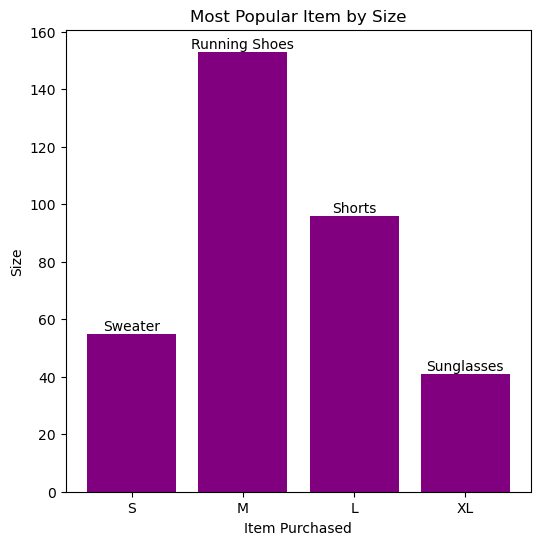

In [ ]:
# What is the most popular item by size?

top_items = most_popular_item_by_size.set_index('Size')
mattyp.figure(figsize=(6, 6))
mattyp.title('Most Popular Item by Size')
mattyp.xlabel('Item Purchased')
mattyp.ylabel('Size')

bars = mattyp.bar(top_items.index, top_items['count'], color='purple')
for bar, item in zip(bars, top_items['Item Purchased']):
    mattyp.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.1,
                item,
                ha='center',
                va='bottom',
                fontsize=10)
    

mattyp.show()

**Question #4: What is the most popular item by size?**

This was another interesting question that I'd like to further explore someday. I figured out how to organize the group.by and bar graph in size order, but I still don't fully understand the relationships at play here. Sweaters were most popular in the size small with 55 purchases. The most popular medium sized item was running shoes with 153 purchases. Shorts were the most popular large item with just under 100 purchases (96). Then the extra-large most popular item was Sunglasses at only 41 purchases. The overall most popular size purchased was medium, and it's interesting that it was shoes and not clothes. The extra-large item being sunglasses is also interesting; seems like a niche item. 

I would venture to say that these results would change if the company offered more plus size options, both in larger sizes and variety of items and options. I would also like to compare these results with gender and color as well to see if anything else can be gleamed from these results.

----------------------------------------------------------------